In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os

solvers = {
    'ga': 'GA',
    'grasp': 'GRASP',
    # 'pli': 'PLI',
    'ts': 'TS' 
}

directories = {
    'ga': 'logs-ga',
    'grasp': 'logs-grasp',
    # 'pli': 'logs-pli',
    'ts': 'logs-ts'
}



In [19]:
all_data = None

# Leitura dos arquivos CSV de cada solver
for k, n in solvers.items():
    dir_path = directories[k]
    file_path = os.path.join(dir_path, f'{k}_all_instances.csv')
    data = pd.read_csv(file_path)
    data['Solver'] = n
    if all_data is None:
        all_data = data
    else:
        all_data = pd.concat([all_data, data], ignore_index=True)

all_data = all_data[['Instance', 'Solver', 'Value']]
all_data['Instance'] = all_data['Instance'].str.rsplit('.', n=1).str[0]
all_data = all_data.pivot(index='Instance', columns='Solver', values='Value')

print(all_data)

Solver            GA   GRASP      TS
Instance                            
instance-11   4634.0  3132.0  4019.0
instance-13   8988.0  1435.0   284.0
instance-14  10668.0  1427.0  1230.0


In [21]:
best_values = all_data.max(axis=1)
ratios_df = best_values.values[:, np.newaxis] / all_data.values
ratios_df = pd.DataFrame(ratios_df, index=all_data.index, columns=all_data.columns)

ratios_df.fillna(1, inplace=True)

print("Dataframe de Fatores de Desempenho (r_p, s):")
print(ratios_df.head())

Dataframe de Fatores de Desempenho (r_p, s):
Solver        GA     GRASP         TS
Instance                             
instance-11  1.0  1.479566   1.153023
instance-13  1.0  6.263415  31.647887
instance-14  1.0  7.475823   8.673171


In [24]:
# gera os valores de tau
num_instances = len(ratios_df)
finite_ratios = ratios_df.values[np.isfinite(ratios_df.values)]
plot_taus = np.unique(finite_ratios[finite_ratios >= 1])

if 1 not in plot_taus:
    plot_taus = np.insert(plot_taus, 0, 1)

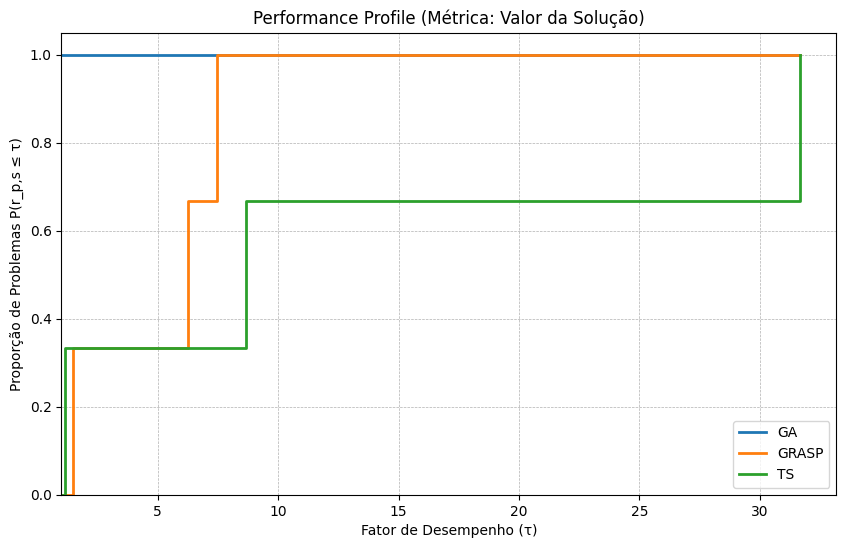

In [26]:
# Gera gráfico
plt.figure(figsize=(10, 6))

for solver in ratios_df.columns:
    solver_ratios = ratios_df[solver]

    # Calcula P(r_p,s <= tau) para cada tau (função de distribuição cumulativa rho_s(tau))
    y_values = []
    for tau in plot_taus:
        count = (solver_ratios <= tau).sum()
        y_values.append(count / num_instances)
        
    plt.plot(plot_taus, y_values, drawstyle='steps-post', label=solver, linewidth=2)

plt.title('Performance Profile (Métrica: Valor da Solução)')
plt.xlabel('Fator de Desempenho (τ)')
plt.ylabel('Proporção de Problemas P(r_p,s ≤ τ)')

plt.xlim(left=1) 

plt.ylim(0, 1.05) 

plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)